In [ ]:
!pip install -q kagglehub pandas pillow matplotlib seaborn opencv-python

import os
import kagglehub

dataset_path = kagglehub.dataset_download(
    "subirbiswas19/freshwater-fish-disease-aquaculture-in-south-asia"
)

print("Dataset path:", dataset_path)

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for filename in files[:10]:
        print(f"{indent}  {filename}")

100%|██████████| 24.8M/24.8M [00:02<00:00, 11.4MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/subirbiswas19/freshwater-fish-disease-aquaculture-in-south-asia/versions/4
4/
  Freshwater Fish Disease Aquaculture in south asia/
    Train.csv
    Train/
      Viral diseases White tail disease/
        Viral diseases White tail disease (226).jpg
        Viral diseases White tail disease (117).jpg
        Viral diseases White tail disease (124).jpg
        Viral diseases White tail disease (186).jpg
        Viral diseases White tail disease (174).jpg
        Viral diseases White tail disease (230).jpg
        Viral diseases White tail disease (169).jpg
        Viral diseases White tail disease (193).jpg
        Viral diseases White tail disease (199).jpg
        Viral diseases White tail disease (152).jpg
      Healthy Fish/
        Healthy Fish (2).jpeg
        Healthy Fish (11).jpeg
        Healthy Fish (28).jpg
        Healthy Fish (37).jpg
        Healthy Fish (118).jpg
        Healthy Fish (77).jpg
        Healthy Fish (19).jpeg
    

In [ ]:
from pathlib import Path
from collections import Counter

dataset_path = Path(dataset_path)
all_files = [p for p in dataset_path.rglob("*") if p.is_file()]

print("Total files:", len(all_files))
print("File types:", Counter(p.suffix.lower() for p in all_files))

csv_files = list(dataset_path.rglob("*.csv"))
json_files = list(dataset_path.rglob("*.json"))
txt_files = list(dataset_path.rglob("*.txt"))

print("CSV files:", csv_files)
print("JSON files:", json_files)
print("TXT files:", txt_files)


Total files: 2451
File types: Counter({'.jpg': 2228, '.jpeg': 158, '.png': 58, '.webp': 6, '.csv': 1})
CSV files: [PosixPath('/root/.cache/kagglehub/datasets/subirbiswas19/freshwater-fish-disease-aquaculture-in-south-asia/versions/4/Freshwater Fish Disease Aquaculture in south asia/Train.csv')]
JSON files: []
TXT files: []


In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    InputLayer,
    Flatten
)
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50

# Scikit-learn
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_curve
)

# Visualization
import seaborn as sns

In [ ]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 50

In [ ]:
dataset = image_dataset_from_directory(
    dataset_path / 'Freshwater Fish Disease Aquaculture in south asia' / 'Train',
    seed = 42,
    shuffle = True,
    image_size = (IMAGE_SIZE , IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 1747 files belonging to 7 classes.


In [ ]:
class_names = dataset.class_names
class_names

['Bacterial Red disease',
 'Bacterial diseases - Aeromoniasis',
 'Bacterial gill disease',
 'Fungal diseases Saprolegniasis',
 'Healthy Fish',
 'Parasitic diseases',
 'Viral diseases White tail disease']

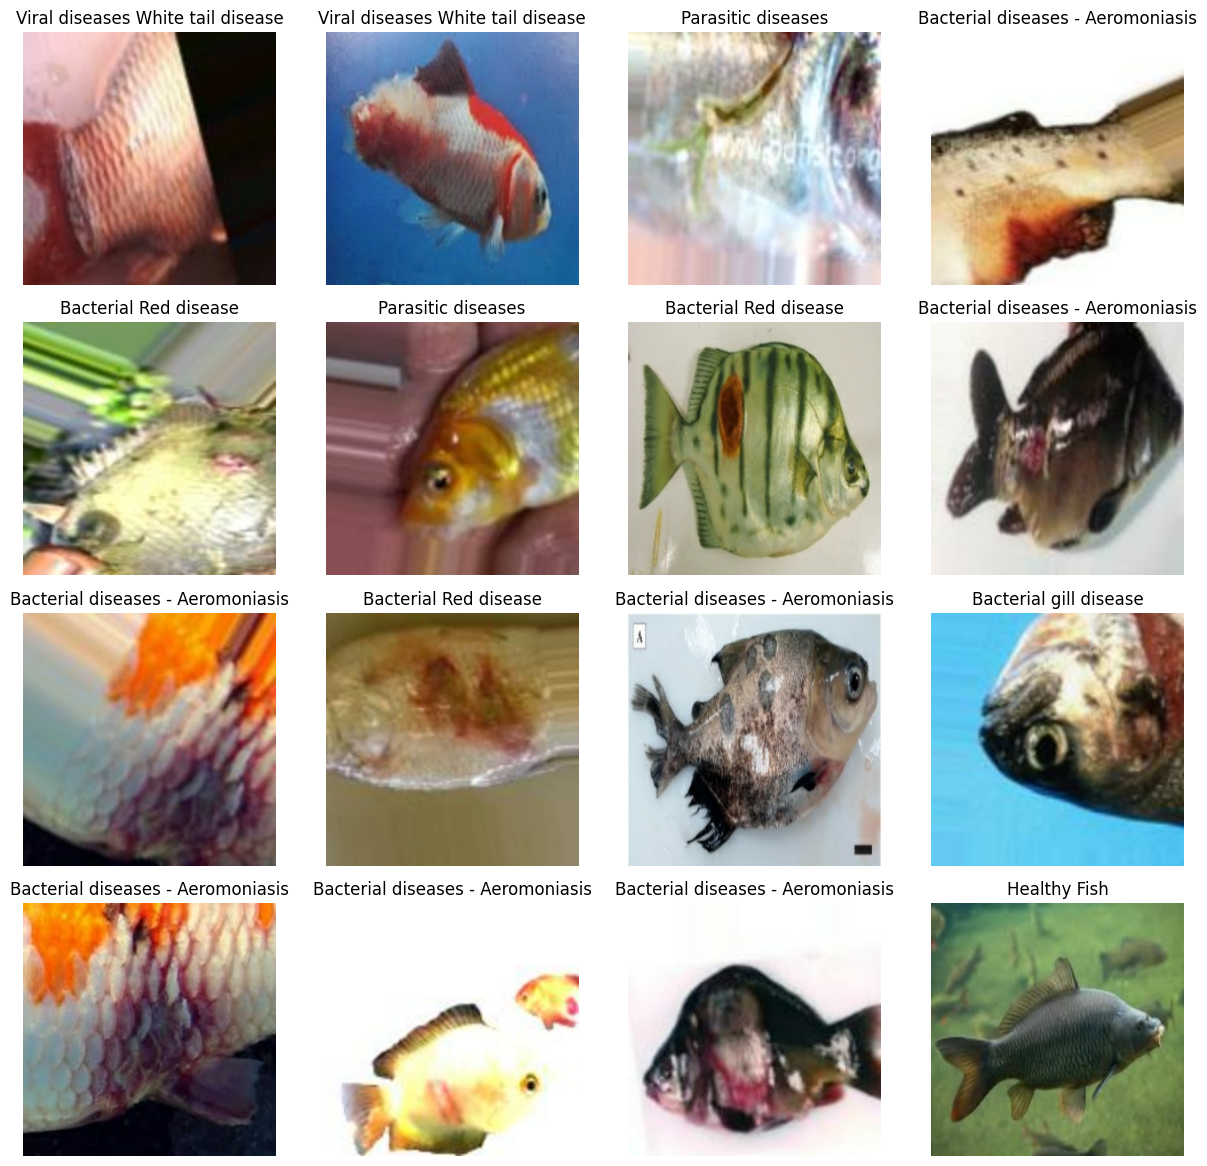

In [ ]:
plt.figure(figsize=(12, 12))
for batch_images, batch_labels in dataset.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(batch_images[i].numpy().astype("uint8"))
        plt.title(class_names[batch_labels[i]])
        plt.tight_layout()
        plt.axis("off")

In [ ]:
TRAIN_SIZE, VALIDATION_SIZE= 0.9, 0.1

In [ ]:
train_batch = int(len(dataset) * TRAIN_SIZE)
train_ds = dataset.take(train_batch)

In [ ]:
val_batch = int(len(dataset) * VALIDATION_SIZE)
validation_ds = dataset.skip(train_batch).take(val_batch)

In [ ]:
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.Rescaling(1./255),
])

In [ ]:
data_augmentation = tf.keras.Sequential([
  layers.RandomRotation(0.2),
])

In [ ]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)

# ResNet50
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=input_shape
)

base_model.trainable = False

# Model
model = Sequential([
    base_model,
    Flatten(),
    Dense(384, activation='relu'),
    Dense(n_classes, activation='softmax')
])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [ ]:
callback = [
    tf.keras.callbacks.ModelCheckpoint(filepath='model.keras')
]

In [ ]:
history = model.fit(
    train_ds,
    batch_size = BATCH_SIZE,
    validation_data = validation_ds,
    verbose = 1,
    epochs = EPOCHS,
    callbacks = callback
)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 45s 634ms/step - accuracy: 0.4381 - loss: 19.5984 - val_accuracy: 0.5750 - val_loss: 1.9850
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 458ms/step - accuracy: 0.6843 - loss: 1.1998 - val_accuracy: 0.6625 - val_loss: 0.9118
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 417ms/step - accuracy: 0.7474 - loss: 0.8206 - val_accuracy: 0.7500 - val_loss: 0.7899
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 25s 505ms/step - accuracy: 0.8208 - loss: 0.6257 - val_accuracy: 0.8062 - val_loss: 0.5415
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 417ms/step - accuracy: 0.8514 - loss: 0.4809 - val_accuracy: 0.8125 - val_loss: 0.7102
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 432ms/step - accuracy: 0.8705 - loss: 0.4408 - val_accuracy: 0.8562 - val_loss: 0.6485
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 26s 531ms/step - accuracy: 0.8948 - loss: 0.3595 - val_accuracy: 0.8938 - val_loss: 0.3372
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 388ms/step - accuracy: 0.9114 - loss: 0.3135 - val_acc

In [ ]:
model = load_model('model.keras')

In [ ]:
test_dataset = image_dataset_from_directory(
    dataset_path / 'Freshwater Fish Disease Aquaculture in south asia' / 'Test',
    seed = 42,
    shuffle = True,
    image_size = (IMAGE_SIZE , IMAGE_SIZE),
    batch_size = BATCH_SIZE
).prefetch(buffer_size=tf.data.AUTOTUNE)

Found 697 files belonging to 7 classes.


In [ ]:
all_predictions = []
all_labels = []
for images, labels in test_dataset:
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    all_predictions.extend(predicted_classes)
    all_labels.extend(labels.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


In [ ]:
accuracy = accuracy_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
precision = precision_score(all_labels, all_predictions, average='weighted')

print("Accuracy: ", accuracy)
print("F1 Score: ", f1)
print("Recall: ", recall)
print("Precision: ", precision)

Accuracy:  0.9899569583931134
F1 Score:  0.989977655563503
Recall:  0.9899569583931134
Precision:  0.9901107325982421


In [ ]:
def predict(model, image):
    img_array = tf.keras.preprocessing.image.img_to_array(image.numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


<Figure size 640x480 with 0 Axes>

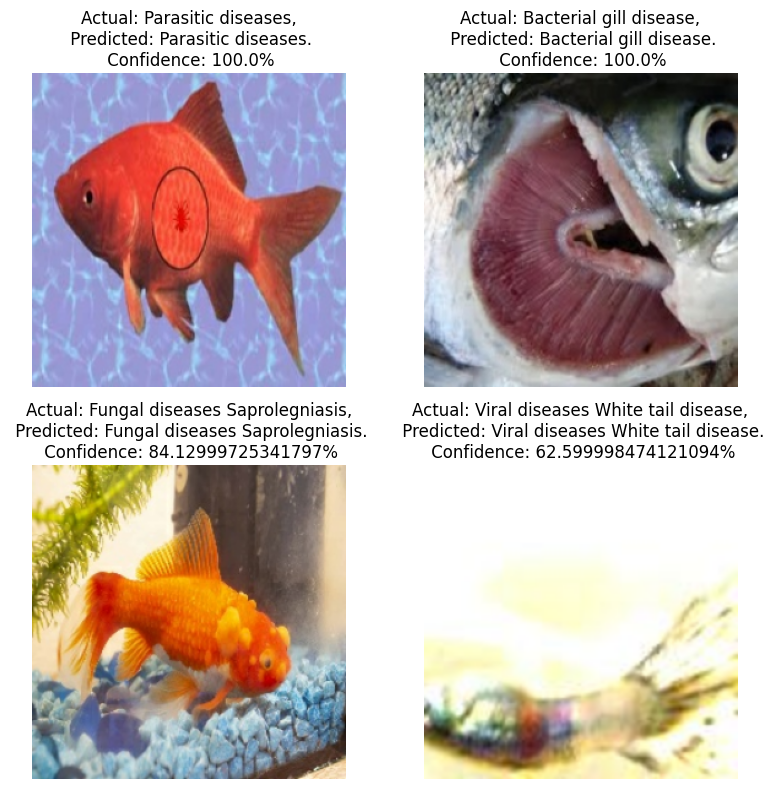

In [ ]:
plt.clf()
plt.figure(figsize=(8, 8))
for images, labels in test_dataset.take(6):
    for i in range(4):
        ax = plt.subplot(2, 2, i + 1)
        if i < len(images):
            ax.imshow(images[i].numpy().astype("uint8"))

            predicted_class, confidence = predict(model, images[i])
            actual_class = class_names[labels[i]]

            ax.set_title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
            ax.axis("off")
plt.tight_layout()
plt.show()